# 07 — Interpretabilidad: qué factores explican las emisiones

**TFM: Predicción de emisiones de CO₂ de buques (THETIS-MRV)**

*Objetivo: responder al segundo de los tres objetivos del TFM —«explicar qué factores influyen más
en las emisiones»— sobre el modelo de trabajo elegido en el notebook 04, y dejar identificadas las
palancas sobre las que actúa el simulador (notebook 08).*

La explicatividad es parte central del trabajo, no un extra.

> **Técnicas.** Se usan la importancia de variables de los ensembles de árboles (`total_gain`), la
> importancia por permutación y SHAP. SHAP es el estándar actual para explicar modelos de árboles y
> resuelve un problema concreto visto en el notebook 04: las medidas de importancia del propio
> XGBoost no son consistentes entre sí. Todo lo que SHAP aporta se contrasta aquí contra las otras
> dos medidas, de modo que la conclusión no depende de una sola técnica.

**Modelo explicado**: XGBoost del nivel de información principal (34 predictoras), R² 0,8337 en
test — el modelo de trabajo que el notebook 04 elige y que el notebook 05 confirma como el explicable de
las dos familias. La sección 7 repite el análisis en el nivel operacional, que es el que usará el
simulador.

> **Tiempo de ejecución**: ~4 minutos. Lo más costoso es TreeSHAP sobre las 21.105 filas de test
> (~70 s) y la importancia por permutación (~10 s).

In [1]:
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

sys.path.insert(0, '../src')
from feature_engineering import RANDOM_STATE
from modelizacion_ml import COLS_NO_PREDICTORAS, TARGET_COL, calcular_metricas

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)

df_principal_ml = pd.read_parquet('../data/processed/mrv_features_principal_ml.parquet')
df_principal_raw = pd.read_parquet('../data/processed/mrv_features_principal_raw.parquet')

# Mismo control de alineamiento que el notebook 05: los índices de una tabla se usan sobre la otra.
claves = ['reporting_year', 'ship_imo_number', TARGET_COL, 'es_train']
assert len(df_principal_ml) == len(df_principal_raw)
assert all((df_principal_ml[c].values == df_principal_raw[c].values).all() for c in claves)

predictoras = [c for c in df_principal_ml.columns if c not in COLS_NO_PREDICTORAS]
train = df_principal_ml[df_principal_ml['es_train']].reset_index(drop=True)
test = df_principal_ml[~df_principal_ml['es_train']].reset_index(drop=True)
test_raw = df_principal_raw[~df_principal_raw['es_train']].reset_index(drop=True)

x_train = train[predictoras].astype('float32')
y_train = train[TARGET_COL].values.astype('float64')
x_test = test[predictoras].astype('float32')
y_test = test[TARGET_COL].values.astype('float64')

# Se reentrena el mismo XGBoost del notebook 04 (mismos hiperparámetros y semilla): es determinista y
# cuesta un segundo, así que el notebook no depende de un pickle externo.
modelo = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, gamma=0,
                      tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)
modelo.fit(x_train, y_train)
prediccion = np.clip(modelo.predict(x_test), 0, None)

t0 = time.time()
explicador = shap.TreeExplainer(modelo)
valores_shap = explicador(x_test)
segundos_shap = time.time() - t0

# TreeSHAP es exacto, no aproximado: la suma de las aportaciones más el valor base tiene que
# reproducir la predicción del modelo. Se comprueba en vez de darlo por hecho.
desviacion = np.abs(valores_shap.values.sum(1) + explicador.expected_value
                    - modelo.predict(x_test)).max()

print(f'R² del modelo explicado (XGBoost, nivel principal) en test: '
      f'{r2_score(y_test, prediccion):.4f}')
print(f'TreeSHAP sobre {len(x_test):,} filas x {len(predictoras)} columnas en {segundos_shap:.1f} s'
      .replace(',', '.'))
print(f'Comprobación de aditividad: max |suma de SHAP + valor base - predicción| = {desviacion:.4f} t')


R² del modelo explicado (XGBoost, nivel principal) en test: 0.8337
TreeSHAP sobre 21.105 filas x 34 columnas en 71.0 s
Comprobación de aditividad: max |suma de SHAP + valor base - predicción| = 0.0547 t


## 1. Un problema previo: 34 columnas no son 7 variables

El modelo trabaja con 34 columnas, pero solo hay **siete variables reales**: el tipo de buque ocupa
14 columnas *one-hot*, la clase de hielo 11, el método de eficiencia 4 y la proporción de missings 2.
Si se listan las importancias columna a columna, el tipo de buque aparece troceado en catorce
pedazos pequeños y parece irrelevante frente a una variable continua que va entera en una sola
columna. Es un artefacto de la codificación, no un resultado.

SHAP permite arreglarlo limpiamente porque **es aditivo**: la aportación de una variable categórica
es la suma de las aportaciones de sus columnas *dummy*. Esa suma sí es interpretable, y es la que se
usa en todo el notebook. La misma agrupación se aplica a las otras dos medidas para que las tres
sean comparables.

In [2]:
def grupo_de(columna):
    """Devuelve la variable original a la que pertenece una columna one-hot."""
    for prefijo in ['ship_type_agrupado_', 'ice_class_', 'te_metodo_', 'prop_missings_']:
        if columna.startswith(prefijo):
            return prefijo[:-1]
    return columna


NOMBRE = {'time_spent_at_sea_hours': 'Horas en el mar',
          'te_valor': 'Eficiencia técnica (EEDI/EIV)',
          'ship_type_agrupado': 'Tipo de buque',
          'ice_class': 'Clase de hielo',
          'te_metodo': 'Método de eficiencia',
          'prop_missings': 'Proporción de missings',
          'es_subcategoria_nueva': 'Subcategoría nueva de EMSA'}

grupos = pd.Series([grupo_de(c) for c in predictoras], index=predictoras)
shap_por_variable = pd.DataFrame(valores_shap.values, columns=predictoras).T.groupby(grupos).sum().T

print(grupos.value_counts().rename('columnas one-hot').to_frame()
      .assign(variable=lambda t: [NOMBRE[i] for i in t.index]).to_string())


                         columnas one-hot                       variable
ship_type_agrupado                     14                  Tipo de buque
ice_class                              11                 Clase de hielo
te_metodo                               4           Método de eficiencia
prop_missings                           2         Proporción de missings
time_spent_at_sea_hours                 1                Horas en el mar
es_subcategoria_nueva                   1     Subcategoría nueva de EMSA
te_valor                                1  Eficiencia técnica (EEDI/EIV)


## 2. Tres formas de medir la importancia, y por qué hay que usar más de una

El notebook 04 ya avisa de esto: la importancia por defecto de XGBoost (`gain`) da un ranking
**inconsistente** con el del modelo lineal y con el de Random Forest, y hay que usar `total_gain`
para que sea comparable. Es la razón de no fiarse de una sola medida.
Aquí se calculan tres, con lógicas distintas:

1. **`total_gain` de XGBoost**: cuánta mejora del error acumula cada
   columna en todos los cortes en que se usa. Se mide **dentro del modelo** y sobre el *train*.
2. **Importancia por permutación**: cuánto
   R² se pierde en **test** al barajar una variable. Es agnóstica al modelo y mide pérdida real de
   capacidad predictiva.
3. **|SHAP| medio**: cuántas toneladas mueve en promedio cada variable la predicción de
   cada buque concreto. Es la única de las tres que está **en unidades del problema**.

In [3]:
importancia_gain = (pd.Series(modelo.get_booster().get_score(importance_type='total_gain'))
                    .reindex(predictoras).fillna(0))

t0 = time.time()
permutacion = permutation_importance(modelo, x_test, y_test, n_repeats=5,
                                     random_state=RANDOM_STATE, n_jobs=-1, scoring='r2')
print(f'Importancia por permutación (5 repeticiones sobre test) en {time.time() - t0:.1f} s')

ranking = pd.DataFrame({'grupo': [grupo_de(c) for c in predictoras],
                        'total_gain': importancia_gain.values,
                        'permutacion': permutacion.importances_mean,
                        'shap_abs': np.abs(valores_shap.values).mean(0)},
                       index=predictoras).groupby('grupo').sum()

for columna in ['total_gain', 'permutacion', 'shap_abs']:
    ranking[columna + '_pct'] = 100 * ranking[columna] / ranking[columna].sum()
    ranking['puesto_' + columna] = ranking[columna].rank(ascending=False).astype(int)

ranking = ranking.assign(variable=[NOMBRE[i] for i in ranking.index]).set_index('variable')
ranking = ranking.sort_values('shap_abs', ascending=False)

tabla_ranking = ranking[['shap_abs', 'shap_abs_pct', 'total_gain_pct', 'permutacion_pct',
                         'puesto_shap_abs', 'puesto_total_gain', 'puesto_permutacion']]
tabla_ranking.columns = ['SHAP medio (t CO2)', 'SHAP %', 'total_gain %', 'permutación %',
                         'puesto SHAP', 'puesto total_gain', 'puesto permutación']
tabla_ranking.round(2).to_csv('../reports/07_ranking_variables.csv')
tabla_ranking.round(2)


Importancia por permutación (5 repeticiones sobre test) en 9.6 s


,SHAP medio (t CO2),SHAP %,total_gain %,permutación %,puesto SHAP,puesto total_gain,puesto permutación
variable,,,,,,,
Tipo de buque,7051.890137,41.570000,34.55,39.64,1,2,2
Horas en el mar,6374.740234,37.580002,42.31,40.97,2,1,1
Eficiencia técnica (EEDI/EIV),1826.479980,10.770000,16.14,13.44,3,3,3
Método de eficiencia,1032.760010,6.090000,3.03,3.17,4,5,4
Clase de hielo,542.799988,3.200000,3.04,2.16,5,4,5
Proporción de missings,113.570000,0.670000,0.86,0.61,6,6,6
Subcategoría nueva de EMSA,21.629999,0.130000,0.07,0.02,7,7,7


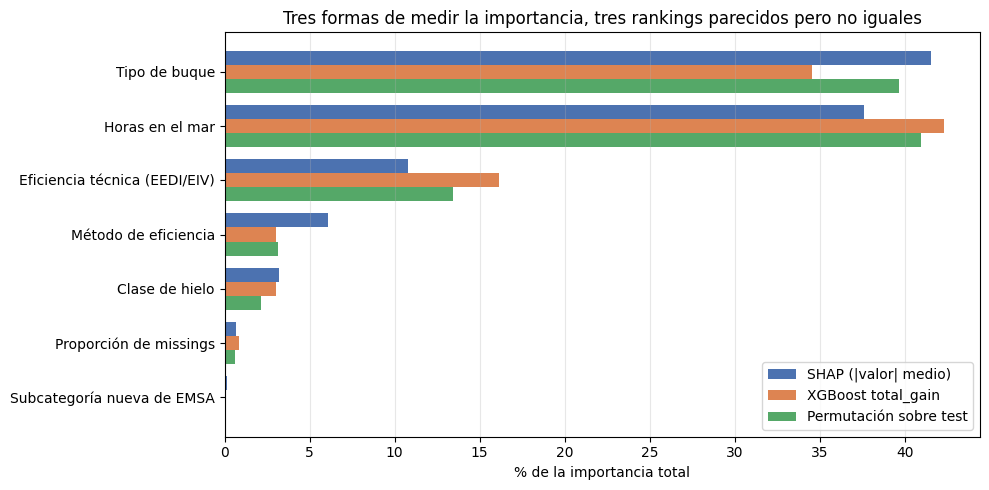

In [4]:
fig, eje = plt.subplots(figsize=(10, 5))

orden = tabla_ranking.sort_values('SHAP %')
posiciones = np.arange(len(orden))
altura = 0.26
eje.barh(posiciones + altura, orden['SHAP %'], height=altura,
         label='SHAP (|valor| medio)', color='#4C72B0')
eje.barh(posiciones, orden['total_gain %'], height=altura,
         label='XGBoost total_gain', color='#DD8452')
eje.barh(posiciones - altura, orden['permutación %'], height=altura,
         label='Permutación sobre test', color='#55A868')
eje.set_yticks(posiciones); eje.set_yticklabels(orden.index)
eje.set_xlabel('% de la importancia total')
eje.set_title('Tres formas de medir la importancia, tres rankings parecidos pero no iguales')
eje.legend(); eje.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/07_ranking_variables.png', dpi=120)
plt.show()


**Las tres medidas coinciden en el fondo y discrepan en el primer puesto**, y la discrepancia es
informativa:

| Variable | SHAP % | total_gain % | permutación % |
|---|---:|---:|---:|
| Tipo de buque | **41,6** | 34,6 | 39,6 |
| Horas en el mar | 37,6 | **42,3** | **41,0** |
| Eficiencia técnica (EEDI/EIV) | 10,8 | 16,1 | 13,4 |
| Método de eficiencia | 6,1 | 3,0 | 3,2 |
| Clase de hielo | 3,2 | 3,0 | 2,2 |
| Proporción de missings | 0,7 | 0,9 | 0,6 |
| Subcategoría nueva de EMSA | 0,1 | 0,1 | 0,0 |

De la tercera posición hacia abajo las tres coinciden en el orden exacto, lo que da bastante
confianza en el resultado. Arriba se intercambian: **SHAP pone primero el tipo de buque y las otras
dos las horas en el mar.**

No es una contradicción, es que miden cosas distintas. Las horas en el mar concentran mucha
capacidad *predictiva* —barajarlas destroza el R², porque son la variable que más separa un buque
activo de uno parado— pero el tipo de buque mueve más *toneladas por buque concreto*: saber que algo
es un portacontenedores en vez de un carguero general desplaza la predicción de un buque medio más
que cualquier valor concreto de horas. La lectura correcta es que **las dos
variables dominantes son el tipo de buque y las horas en el mar, y juntas explican en torno al 80%**;
discutir cuál es la primera es discutir sobre la definición de "importante".

La lectura útil para el simulador ya aparece aquí: de esas dos, **solo una es accionable**. El tipo
de buque no se cambia; las horas en el mar sí.

## 3. SHAP no solo ordena: dice en qué dirección

Es lo que ninguna de las otras dos medidas da. El gráfico de enjambre pone una fila por
columna y un punto por buque del test: la posición horizontal es cuántas toneladas mueve esa columna
la predicción de ese buque, y el color es si el valor de la variable era alto o bajo.

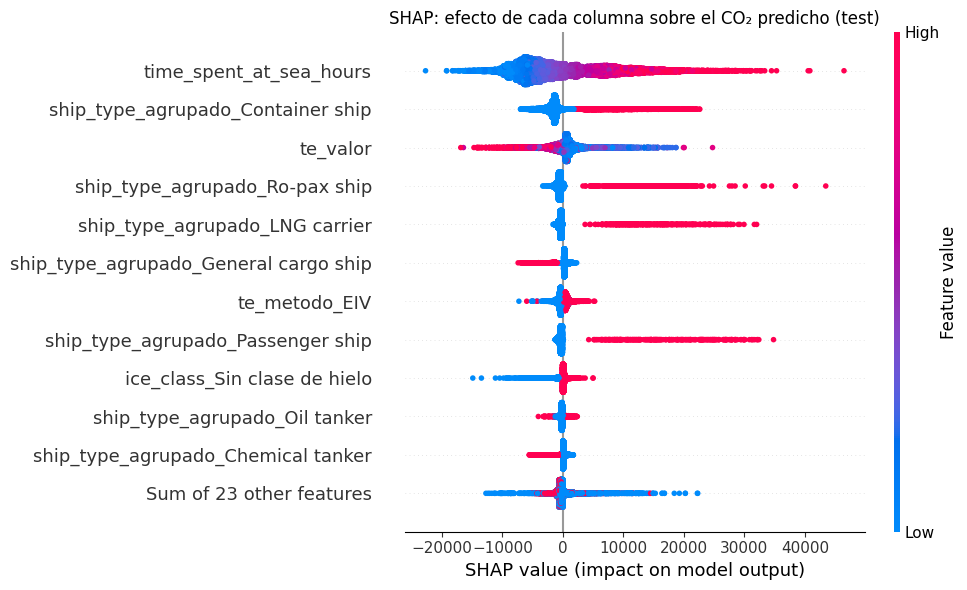

In [5]:
shap.plots.beeswarm(valores_shap, max_display=12, show=False)
figura = plt.gcf()
figura.set_size_inches(10, 6)
plt.title('SHAP: efecto de cada columna sobre el CO₂ predicho (test)')
plt.tight_layout()
plt.savefig('../reports/07_shap_beeswarm.png', dpi=120)
plt.show()


Se leen tres cosas de un vistazo, y las tres son coherentes con la física del problema:

- **Horas en el mar**: la cola roja se va con claridad a la derecha. Más horas navegando, más CO₂, y
  el efecto es muy asimétrico — hay buques que suman decenas de miles de toneladas por este solo
  factor, mientras que los amarrados restan poco (no se puede emitir menos de cero).
- **Portacontenedores** (`ship_type_agrupado_Container ship`): estar en esa categoría (rojo)
  desplaza fuertemente hacia arriba; no estarlo (azul) es una corrección pequeña y negativa. Es el
  patrón típico de una *dummy* de una categoría minoritaria y muy emisora.
- **Eficiencia técnica**: valores altos del índice EEDI/EIV —peor eficiencia por tonelada-milla—
  empujan hacia arriba. Que el modelo haya aprendido eso **sin que nadie se lo diga** es una
  validación de sentido físico del modelo.

## 4. Cuánto cuesta cada hora de navegación, según el tipo de buque

El gráfico de dependencia toma una variable y enfrenta su valor con su aportación. Es lo que
convierte la interpretabilidad en algo cuantitativo: en vez de "las horas importan", **cuántas
toneladas por hora**.

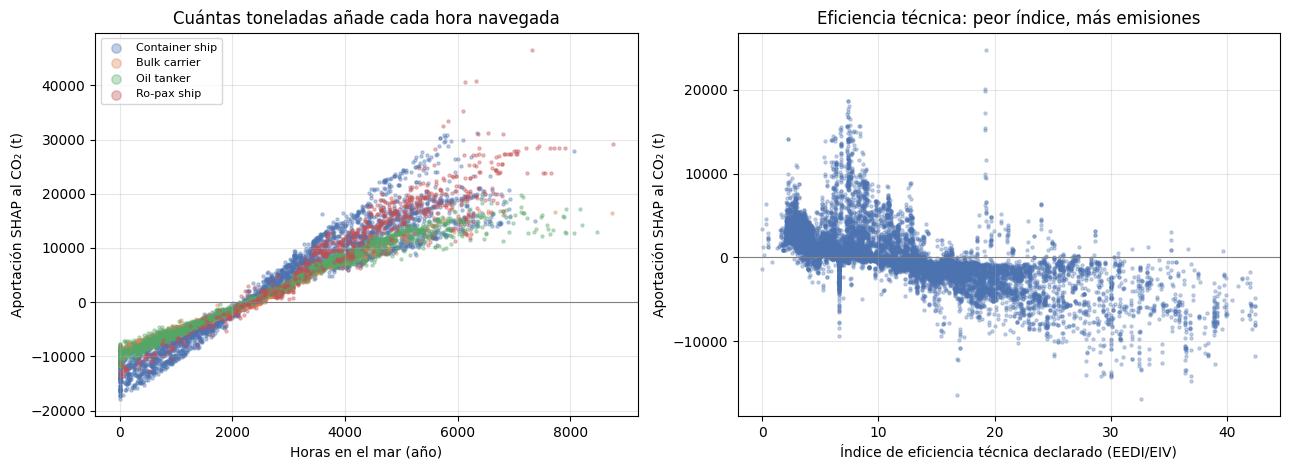

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.8))

tipos = test_raw['ship_type_agrupado'].values
destacados = {'Container ship': '#4C72B0', 'Bulk carrier': '#DD8452',
              'Oil tanker': '#55A868', 'Ro-pax ship': '#C44E52'}
for tipo, color in destacados.items():
    marca = tipos == tipo
    ejes[0].scatter(x_test['time_spent_at_sea_hours'][marca],
                    shap_por_variable['time_spent_at_sea_hours'][marca],
                    s=5, alpha=0.35, label=tipo, color=color)
ejes[0].axhline(0, color='grey', lw=0.8)
ejes[0].set_xlabel('Horas en el mar (año)')
ejes[0].set_ylabel('Aportación SHAP al CO₂ (t)')
ejes[0].set_title('Cuántas toneladas añade cada hora navegada')
ejes[0].legend(markerscale=3, fontsize=8); ejes[0].grid(alpha=0.3)

declarado = x_test['te_valor'].values > 0
ejes[1].scatter(x_test['te_valor'][declarado], shap_por_variable['te_valor'][declarado],
                s=5, alpha=0.3, color='#4C72B0')
ejes[1].axhline(0, color='grey', lw=0.8)
ejes[1].set_xlabel('Índice de eficiencia técnica declarado (EEDI/EIV)')
ejes[1].set_ylabel('Aportación SHAP al CO₂ (t)')
ejes[1].set_title('Eficiencia técnica: peor índice, más emisiones'); ejes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/07_dependencia.png', dpi=120)
plt.show()


In [7]:
# Pendiente de la recta ajustada a cada tipo: toneladas de CO2 por hora navegada, según el modelo.
filas_pendiente = []
for tipo in sorted(set(tipos)):
    marca = tipos == tipo
    if marca.sum() < 100:
        continue
    pendiente = np.polyfit(x_test['time_spent_at_sea_hours'][marca],
                           shap_por_variable['time_spent_at_sea_hours'][marca], 1)[0]
    filas_pendiente.append({'tipo': tipo, 'n': int(marca.sum()),
                            't_CO2_por_hora_navegada': pendiente})

pendientes = pd.DataFrame(filas_pendiente).sort_values('t_CO2_por_hora_navegada', ascending=False)
pendientes.round(3).to_csv('../reports/07_pendiente_horas_por_tipo.csv', index=False)
pendientes.round(3)


,tipo,n,t_CO2_por_hora_navegada
6,LNG carrier,507,6.484
9,Passenger ship,277,6.292
11,Ro-pax ship,712,5.629
2,Container ship,3183,5.568
3,Container/ro-ro cargo ship,123,4.791
10,Refrigerated cargo carrier,211,4.787
12,Ro-ro ship,353,4.603
7,Oil tanker,3257,4.199
13,Vehicle carrier,760,4.160
0,Bulk carrier,6337,4.076


La pendiente es **la cifra más directamente utilizable de todo el notebook**, porque está en
unidades que un armador entiende: toneladas de CO₂ por hora de navegación.

| Tipo de buque | t CO₂ por hora navegada |
|---|---:|
| LNG carrier | 6,48 |
| Passenger ship | 6,29 |
| Ro-pax ship | 5,63 |
| Container ship | 5,57 |
| Container/ro-ro cargo ship | 4,79 |
| Refrigerated cargo carrier | 4,79 |
| Ro-ro ship | 4,60 |
| Oil tanker | 4,20 |
| Vehicle carrier | 4,16 |
| Bulk carrier | 4,08 |
| Gas carrier | 3,72 |
| Chemical tanker | 3,39 |
| Other ship types | 3,30 |
| General cargo ship | 3,02 |

Un metanero emite **más del doble por hora** que un carguero general (6,48 frente a 3,02), y el
rango completo va de 3,0 a 6,5 toneladas por hora. Traducido a negocio: **una hora de navegación
ahorrada no vale lo mismo en toda la flota**, y una política de reducción rinde algo más del doble
(2,15 veces) aplicada a metaneros, pasaje, ro-pax y portacontenedores que aplicada a la carga seca.
Es exactamente el tipo de conclusión que el simulador (notebook 08) tiene que poder cuantificar.

El panel derecho confirma la otra relación esperable: peor índice de eficiencia técnica, más
emisiones. La nube de puntos en el eje horizontal cerca de cero corresponde a los buques que no
declaran índice; el modelo los trata como un grupo aparte, que es lo que explica el 6% que se lleva
la variable "método de eficiencia" — un metadato, no una causa física.

## 5. Del modelo global al buque concreto

Lo que distingue a SHAP de una tabla de importancias es que **descompone cada predicción
individual**. Tres casos del test, elegidos por criterios objetivos y no a mano: el mayor emisor, el
peor error absoluto del modelo, y un emisor pequeño bien predicho.

In [8]:
error = np.abs(y_test - prediccion)
pequeno_bien_predicho = pd.Series(np.where((y_test < 3000) & (error < 200), error, np.nan)).idxmax()

casos = {'Mayor emisor del test': int(np.argmax(y_test)),
         'Peor error absoluto': int(np.argmax(error)),
         'Emisor pequeño bien predicho': int(pequeno_bien_predicho)}

casos_df = pd.DataFrame([
    {'caso': etiqueta, 'buque': test['ship_name'].iloc[i],
     'tipo': test_raw['ship_type_agrupado'].iloc[i], 'año': int(test['reporting_year'].iloc[i]),
     'CO2_real': y_test[i], 'CO2_predicho': float(prediccion[i]),
     'error': float(prediccion[i] - y_test[i]),
     'horas_mar': float(x_test['time_spent_at_sea_hours'].iloc[i])}
    for etiqueta, i in casos.items()])
casos_df.to_csv('../reports/07_casos_locales.csv', index=False)
casos_df.round(1)


,caso,buque,tipo,año,CO2_real,CO2_predicho,error,horas_mar
0,Mayor emisor del test,CRUISE BARCELONA,Ro-pax ship,2021,153314.6,103036.2,-50278.4,5745.6
1,Peor error absoluto,DUKHAN,Gas carrier,2019,98875.5,20007.7,-78867.8,6722.8
2,Emisor pequeño bien predicho,MORNING TIDE,General cargo ship,2024,2431.3,2231.6,-199.7,1009.2


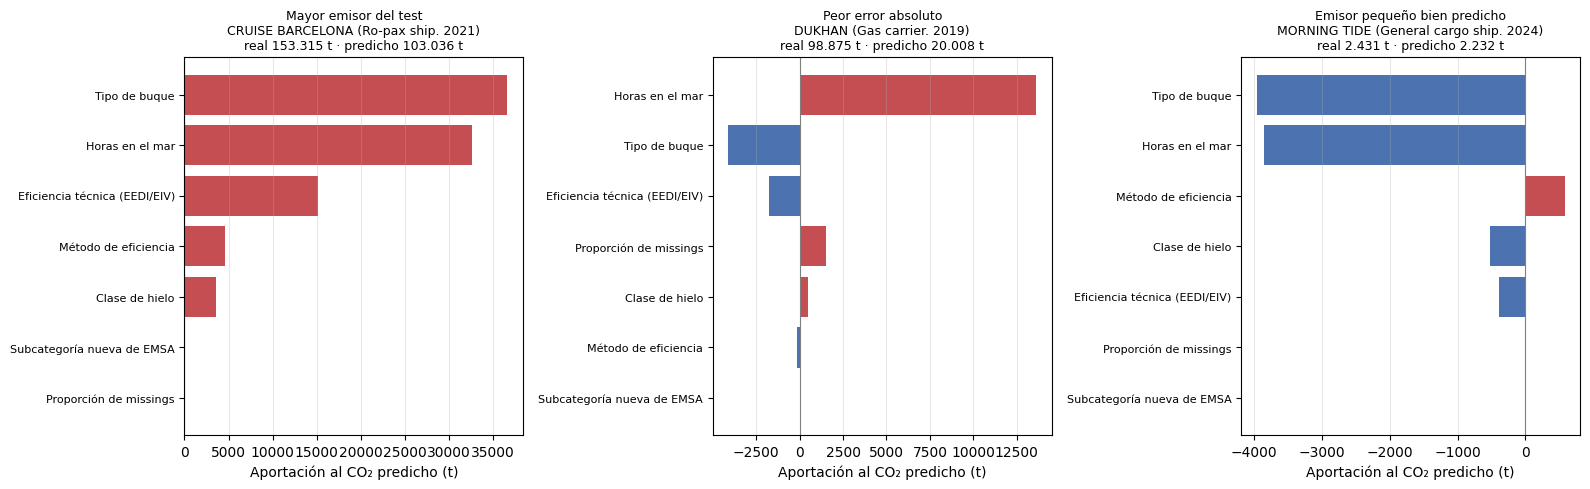

In [9]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 5))

for eje, (etiqueta, i) in zip(ejes, casos.items()):
    aportaciones = shap_por_variable.iloc[i].sort_values(key=np.abs, ascending=False)
    aportaciones.index = [NOMBRE[k] for k in aportaciones.index]
    eje.barh(range(len(aportaciones))[::-1], aportaciones.values,
             color=['#C44E52' if v > 0 else '#4C72B0' for v in aportaciones.values])
    eje.set_yticks(range(len(aportaciones))[::-1])
    eje.set_yticklabels(aportaciones.index, fontsize=8)
    eje.axvline(0, color='grey', lw=0.8)
    eje.set_title(f'{etiqueta}\n{test["ship_name"].iloc[i]} '
                  f'({test_raw["ship_type_agrupado"].iloc[i]}, {int(test["reporting_year"].iloc[i])})\n'
                  f'real {y_test[i]:,.0f} t · predicho {prediccion[i]:,.0f} t'.replace(',', '.'),
                  fontsize=9)
    eje.set_xlabel('Aportación al CO₂ predicho (t)'); eje.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/07_casos_locales.png', dpi=120)
plt.show()


Los tres casos cuentan la misma historia desde ángulos distintos, y es la historia que cierra el
diagnóstico abierto en los notebooks 04 y 05.

- **CRUISE BARCELONA** (ro-pax, 2021), el mayor emisor del test con 153.315 t: el modelo predice
  103.036 t, **50.000 toneladas por debajo**. Ve las 5.746 horas en el mar y ve que es un ro-pax,
  y con eso llega a un ro-pax grande — pero no puede llegar a *este* ro-pax, un crucero de 3.000
  pasajeros con una demanda hotelera enorme.
- **DUKHAN** (gas carrier, 2019), el peor error absoluto: 98.876 t reales frente a 20.008 t
  predichas. Es un metanero de gran porte, y el modelo lo trata como un gasero medio.
- **MORNING TIDE** (carguero general, 2024): 2.431 t reales, 2.232 predichas. Con 1.009 horas en el
  mar y un tipo de buque homogéneo, el modelo acierta con holgura.

El patrón es inequívoco: **el modelo falla exactamente donde el tamaño del buque importa y no está
en el dato**. El MRV público no publica arqueo bruto, porte, número de pasajeros ni consumo
hotelero, así que dentro de cada tipo de buque el modelo solo puede predecir algo parecido al buque
medio de esa categoría. Los dos errores grandes son buques enormes de categorías donde la dispersión
de tamaño es brutal (cruceros, metaneros); el acierto es un buque de una categoría homogénea.

Esto convierte en cuantitativa una limitación que los notebooks anteriores enuncian de forma
cualitativa: **no es un problema del algoritmo, y ni la red neuronal ni la mezcla lo arreglan**
(notebook 05, sección 8). Una vía sería enriquecer con una fuente externa de características del
buque —IMO GISIS o Equasis—; la sección 8 muestra que hay otra sin salir del propio registro.

## 6. ¿Explica el modelo todos los tipos de buque con las mismas variables?

Los notebooks 04 y 05 dejan una pregunta abierta: carga general y ro-pax se predicen mucho peor que el
resto (R² ~0,5 y ~0,58) en **las dos familias de modelos**. SHAP permite mirar dentro y ver si el
modelo se apoya en variables distintas según el tipo.

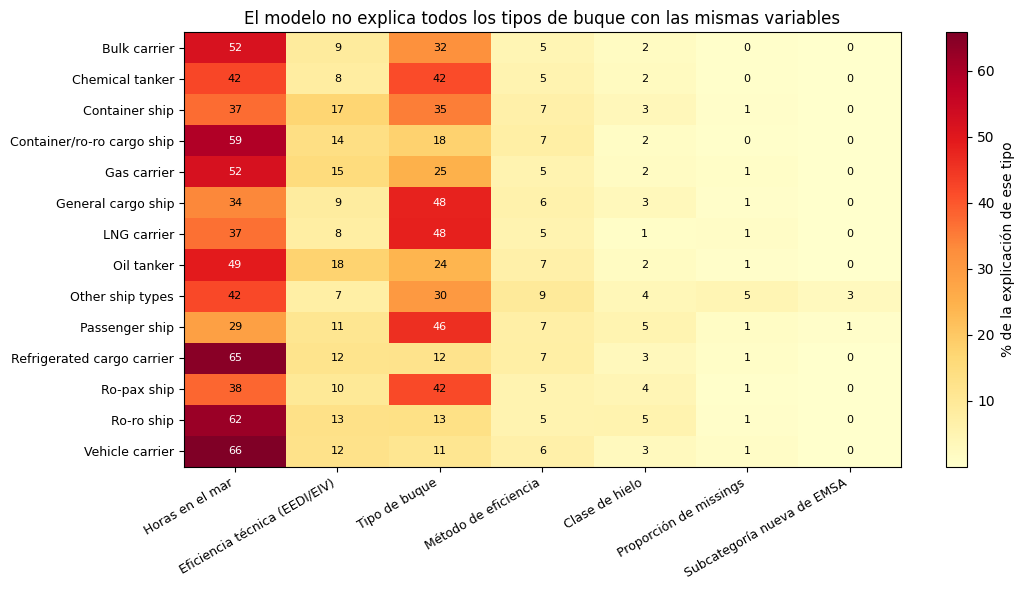

In [10]:
porcentajes = []
for tipo in sorted(set(tipos)):
    marca = tipos == tipo
    if marca.sum() < 100:
        continue
    medias = shap_por_variable[marca].abs().mean()
    porcentajes.append(pd.Series(100 * medias / medias.sum(), name=tipo))

mapa = pd.DataFrame(porcentajes)
mapa.columns = [NOMBRE[c] for c in mapa.columns]
mapa = mapa[['Horas en el mar', 'Eficiencia técnica (EEDI/EIV)', 'Tipo de buque',
             'Método de eficiencia', 'Clase de hielo', 'Proporción de missings',
             'Subcategoría nueva de EMSA']]
mapa.round(1).to_csv('../reports/07_shap_por_tipo_buque.csv')

fig, eje = plt.subplots(figsize=(11, 6))
imagen = eje.imshow(mapa.values, cmap='YlOrRd', aspect='auto')
eje.set_xticks(range(mapa.shape[1]))
eje.set_xticklabels(mapa.columns, rotation=30, ha='right', fontsize=9)
eje.set_yticks(range(mapa.shape[0])); eje.set_yticklabels(mapa.index, fontsize=9)
for i in range(mapa.shape[0]):
    for j in range(mapa.shape[1]):
        eje.text(j, i, f'{mapa.values[i, j]:.0f}', ha='center', va='center', fontsize=8,
                 color='white' if mapa.values[i, j] > 45 else 'black')
plt.colorbar(imagen, label='% de la explicación de ese tipo')
eje.set_title('El modelo no explica todos los tipos de buque con las mismas variables')

plt.tight_layout()
plt.savefig('../reports/07_shap_por_tipo_buque.png', dpi=120)
plt.show()


La respuesta es que **no**, y explica bastante bien dónde falla:

- Donde el modelo funciona mejor, se apoya en la **operación**: vehicle carrier (65,8% de la
  explicación son las horas en el mar), refrigerated cargo (64,5%), ro-ro (62,1%),
  container/ro-ro (59,0%). Son tipos donde saber cuánto navegó el buque casi basta, y el R² del
  notebook 05 los sitúa entre 0,53 y 0,83.
- Donde el modelo funciona peor, se apoya en la **etiqueta**: carga general (47,8% es el propio tipo
  de buque, y solo un 33,5% las horas), LNG carrier (48,3%), pasaje (45,8%), ro-pax (41,8%). Cuando
  casi la mitad de la explicación es "es de esta categoría", el modelo está prediciendo el promedio
  de la categoría, y eso es justo lo que produce un R² de 0,5.

Es la misma conclusión de la sección anterior vista en agregado: **cuando el modelo se apoya en la
categoría en vez de en la operación, es porque le falta la variable que distinguiría a un buque de
otro dentro de esa categoría — el tamaño.** Y encaja con que sean precisamente carga general
(barcos de 3.000 a 30.000 toneladas de porte bajo la misma etiqueta) y pasaje/ro-pax (desde un ferry
pequeño hasta el CRUISE BARCELONA) las categorías más heterogéneas de la flota.

## 7. El nivel operacional: qué cambia al añadir la velocidad

Todo lo anterior es el nivel de información principal. El **nivel operacional** añade la velocidad
media reconstruida en el notebook 03, y es candidato para el simulador (notebook 08) — el notebook 05
mide que XGBoost llega a R² 0,9115 y la mezcla con la red a **0,9179**. La pregunta aquí no
es cuánto mejora, que ya se sabe, sino **de dónde sale la mejora**.

> **Cobertura de la velocidad.** Con las dos convenciones de nombre del ratio combustible/distancia
> combinadas (notebook 03, sección 4), `velocidad_nudos` cubre el 94,0% de las filas y solo 1.221
> filas de test quedan sin velocidad. Con un tercio de las velocidades ausentes, el peso de la
> velocidad quedaría subestimado (tipo de buque 22,9%, velocidad 17,1%, palanca operativa 59,8%).

In [11]:
df_operacional_ml = pd.read_parquet('../data/processed/mrv_features_operacional_ml.parquet')

todas_oper = [c for c in df_operacional_ml.columns if c not in COLS_NO_PREDICTORAS]
cols_base_oper = [c for c in todas_oper if c not in ('distancia_nm', 'velocidad_nudos')]
cols_oper = cols_base_oper + ['velocidad_nudos']

train_oper = df_operacional_ml[df_operacional_ml['es_train']].reset_index(drop=True)
test_oper = df_operacional_ml[~df_operacional_ml['es_train']].reset_index(drop=True)
x_train_oper = train_oper[cols_oper].astype('float32')
x_test_oper = test_oper[cols_oper].astype('float32')

modelo_oper = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, gamma=0,
                           tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)
modelo_oper.fit(x_train_oper, train_oper[TARGET_COL].values.astype('float64'))

valores_shap_oper = shap.TreeExplainer(modelo_oper)(x_test_oper)
NOMBRE['velocidad_nudos'] = 'Velocidad media'
grupos_oper = pd.Series([grupo_de(c) for c in cols_oper], index=cols_oper)
shap_oper = (pd.DataFrame(valores_shap_oper.values, columns=cols_oper)
             .T.groupby(grupos_oper).sum().T)

medias_oper = shap_oper.abs().mean()
comparacion = (pd.DataFrame({'variable': [NOMBRE[i] for i in medias_oper.index],
                             'operacional_%': 100 * medias_oper.values / medias_oper.values.sum()})
               .set_index('variable')
               .join(tabla_ranking[['SHAP %']].rename(columns={'SHAP %': 'principal_%'}), how='outer')
               .fillna(0)[['principal_%', 'operacional_%']]
               .sort_values('operacional_%', ascending=False))
comparacion.round(1).to_csv('../reports/07_ranking_operacional.csv')

print(f'XGBoost del nivel operacional | {len(cols_oper)} predictoras | '
      f'{int(np.isnan(x_test_oper["velocidad_nudos"].values).sum()):,} filas de test sin velocidad '
      f'(TreeSHAP las trata igual que el modelo: NaN nativo)'.replace(',', '.'))
comparacion.round(1)


XGBoost del nivel operacional | 35 predictoras | 1.221 filas de test sin velocidad (TreeSHAP las trata igual que el modelo: NaN nativo)


,principal_%,operacional_%
variable,,
Horas en el mar,37.599998,38.5
Velocidad media,0.000000,28.5
Tipo de buque,41.599998,17.4
Eficiencia técnica (EEDI/EIV),10.800000,8.7
Método de eficiencia,6.100000,4.7
Clase de hielo,3.200000,1.5
Proporción de missings,0.700000,0.6
Subcategoría nueva de EMSA,0.100000,0.0


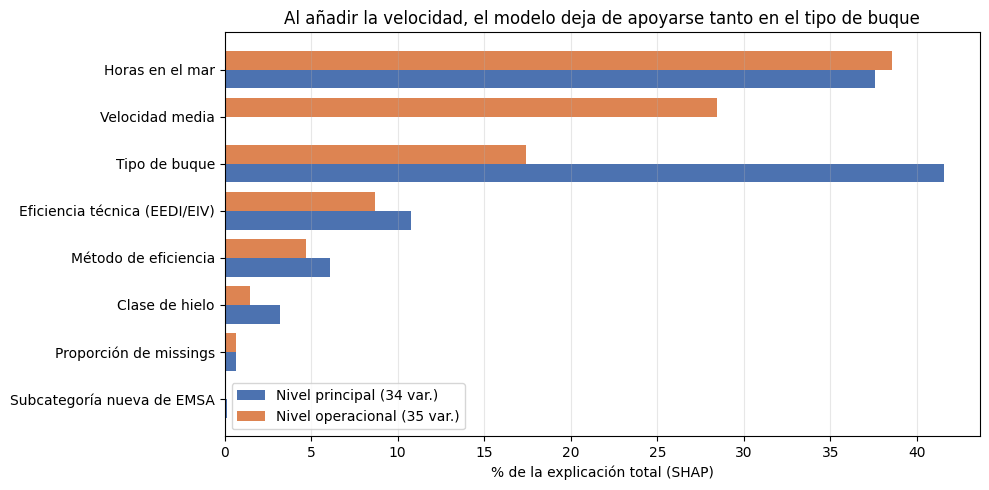

In [12]:
fig, eje = plt.subplots(figsize=(10, 5))

orden = comparacion.sort_values('operacional_%')
posiciones = np.arange(len(orden))
eje.barh(posiciones - 0.2, orden['principal_%'], height=0.4, color='#4C72B0',
         label='Nivel principal (34 var.)')
eje.barh(posiciones + 0.2, orden['operacional_%'], height=0.4, color='#DD8452',
         label='Nivel operacional (35 var.)')
eje.set_yticks(posiciones); eje.set_yticklabels(orden.index)
eje.set_xlabel('% de la explicación total (SHAP)')
eje.set_title('Al añadir la velocidad, el modelo deja de apoyarse tanto en el tipo de buque')
eje.legend(); eje.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/07_ranking_operacional.png', dpi=120)
plt.show()


**El resultado es que la velocidad no añade explicación: se la quita al tipo de buque.**

| Variable | Nivel principal | Nivel operacional |
|---|---:|---:|
| Horas en el mar | 37,6% | **38,5%** |
| Tipo de buque | **41,6%** | 17,4% |
| Velocidad media | — | **28,5%** |
| Eficiencia técnica (EEDI/EIV) | 10,8% | 8,7% |
| Método de eficiencia | 6,1% | 4,7% |
| Clase de hielo | 3,2% | 1,5% |

El tipo de buque cae **de 41,6% a 17,4%**, a menos de la mitad, y la velocidad entra directamente
como **segunda variable del modelo, con un 28,5%**. La interpretación es directa y es un resultado del trabajo: en el nivel principal, **"tipo de buque"
estaba haciendo en buena parte de sustituto de cómo opera el buque** — un portacontenedores emitía
más no solo por ser un portacontenedores, sino porque los portacontenedores navegan rápido. Cuando
se le da al modelo la velocidad de verdad, deja de necesitar la etiqueta para inferirla.

Esto tiene una lectura que va más allá de lo técnico: **el nivel principal
sobreestima el peso de lo estructural y subestima el de lo operativo**. Si se usara el nivel
principal para orientar una política de reducción, la conclusión sería fatalista ("depende sobre
todo de qué flota tengas"); con la velocidad en el modelo, la conclusión cambia y la operación pasa
a ser la palanca dominante. Es la diferencia entre un informe que dice "no hay mucho que hacer" y
uno que dice dónde actuar.

## 8. El tamaño del buque: la limitación que se levanta

Las secciones 5 y 6 cierran con un diagnóstico: al modelo le falta el tamaño del buque, que el MRV
público no publica —arqueo bruto, porte, pasajeros, consumo hotelero—.

Se puede resolver sin GISIS ni Equasis: el notebook 03 (sección 5) reconstruye la
capacidad de carga de cada buque despejándola del cociente entre la intensidad por milla y la
intensidad por trabajo de transporte, ambas publicadas por el propio MRV. Cubre el 98,2% de las
filas.

Esta sección repite el análisis de la sección 2 sobre los dos niveles nuevos y responde a la
pregunta que el diagnóstico deja abierta: **¿cuánto de lo que el modelo atribuía al tipo de buque
era en realidad tamaño?**

Un apunte de método. Las seis columnas de capacidad no son un *one-hot* de una misma variable, pero
sí son seis medidas de un mismo concepto en unidades distintas —toneladas, m³, pasajeros— de las que
cada buque tiene solo las que le aplican. Agruparlas sumando sus aportaciones SHAP es por tanto
legítimo y necesario para comparar contra el resto de variables, exactamente por el mismo argumento
de aditividad de la sección 1. El desglose por unidad se mira aparte.

In [13]:
df_tamano_ml = pd.read_parquet('../data/processed/mrv_features_tamano_ml.parquet')
df_oper_tam_ml = pd.read_parquet('../data/processed/mrv_features_operacional_tamano_ml.parquet')

NOMBRE['capacidad'] = 'Capacidad de carga'
NOMBRE['capacidad_utilizada'] = 'Carga movida en el año'


def grupo_de_v2(columna):
    """Como `grupo_de`, pero agrupa ademas las seis columnas de capacidad de diseno en una sola.

    `capacidad_utilizada` se deja FUERA del grupo a proposito: no es una caracteristica del buque
    sino lo que el buque movio ese ano concreto, y en la seccion 9 cuenta como palanca operativa.
    """
    if columna.startswith('capacidad_') and columna != 'capacidad_utilizada':
        return 'capacidad'
    if columna == 'capacidad_estimada':
        return 'capacidad'
    return grupo_de(columna)


def shap_por_nivel(df_ml, columnas, agrupador=grupo_de_v2):
    """Entrena el mismo XGBoost sobre `columnas` y devuelve (% SHAP por variable, shap agrupado, modelo)."""
    tr = df_ml[df_ml['es_train']].reset_index(drop=True)
    te = df_ml[~df_ml['es_train']].reset_index(drop=True)
    xtr, xte = tr[columnas].astype('float32'), te[columnas].astype('float32')
    mod = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, gamma=0,
                       tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)
    mod.fit(xtr, tr[TARGET_COL].values.astype('float64'))
    vals = shap.TreeExplainer(mod)(xte)
    g = pd.Series([agrupador(c) for c in columnas], index=columnas)
    agrupado = pd.DataFrame(vals.values, columns=columnas).T.groupby(g).sum().T
    medias = agrupado.abs().mean()
    pct = pd.Series(100 * medias.values / medias.values.sum(),
                    index=[NOMBRE[i] for i in medias.index])
    return pct, agrupado, mod, vals, xte, te


cols_tam = [c for c in df_tamano_ml.columns if c not in COLS_NO_PREDICTORAS]
cols_ot = [c for c in df_oper_tam_ml.columns if c not in COLS_NO_PREDICTORAS and c != 'distancia_nm']

t0 = time.time()
pct_tam, shap_tam, modelo_tam, vals_tam, x_test_tam, test_tam = shap_por_nivel(df_tamano_ml, cols_tam)
pct_ot, shap_ot, modelo_ot, vals_ot, x_test_ot, test_ot = shap_por_nivel(df_oper_tam_ml, cols_ot)
print(f'Dos niveles nuevos entrenados y explicados en {time.time() - t0:.1f} s')

niveles_shap = (pd.DataFrame({'1. principal': tabla_ranking['SHAP %']})
                .join(pd.DataFrame({'2. tamano': pct_tam}), how='outer')
                .join(comparacion[['operacional_%']].rename(columns={'operacional_%': '3. operacional'}), how='outer')
                .join(pd.DataFrame({'4. operacional + tamano': pct_ot}), how='outer')
                .fillna(0).sort_values('4. operacional + tamano', ascending=False)
                .rename_axis('variable'))
niveles_shap.round(1).to_csv('../reports/07_niveles_shap.csv')
niveles_shap.round(1)

Dos niveles nuevos entrenados y explicados en 145.6 s


,1. principal,2. tamano,3. operacional,4. operacional + tamano
variable,,,,
Horas en el mar,37.599998,45.299999,38.5,39.400002
Velocidad media,0.000000,0.000000,28.5,26.900000
Capacidad de carga,0.000000,28.299999,0.0,18.500000
Tipo de buque,41.599998,18.799999,17.4,6.600000
Carga movida en el año,0.000000,0.000000,0.0,2.900000
Eficiencia técnica (EEDI/EIV),10.800000,4.000000,8.7,2.700000
Método de eficiencia,6.100000,2.400000,4.7,2.200000
Proporción de missings,0.700000,0.600000,0.6,0.500000
Clase de hielo,3.200000,0.500000,1.5,0.200000


Aportacion SHAP de cada columna de capacidad, en % del total del nivel 2:
capacidad_mass        9.57
capacidad_estimada    9.47
capacidad_pax         7.97
capacidad_volume      2.32
capacidad_dwt         2.28
capacidad_freight     1.11

Suma de las seis: 32.7%


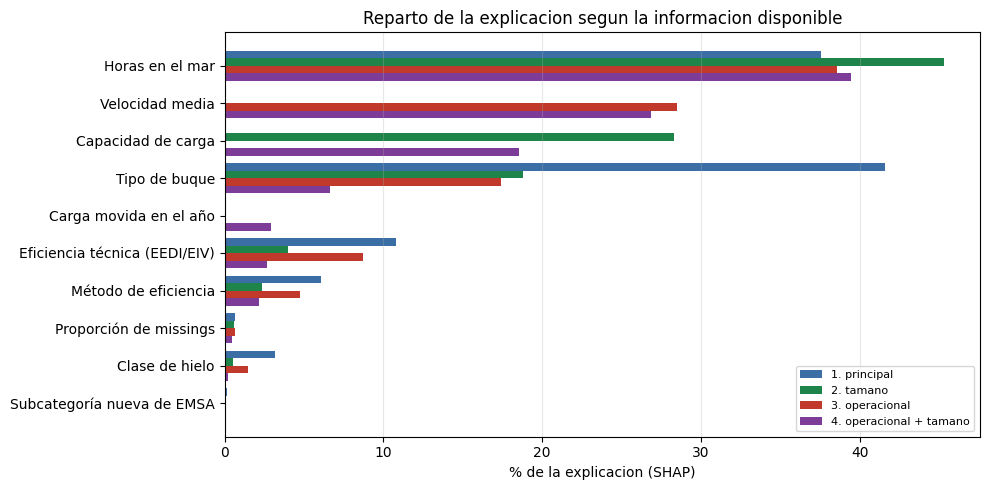

In [14]:
# Desglose de la capacidad por unidad del Reglamento 2016/1928, dentro del nivel 2.
detalle_cap = (pd.DataFrame(vals_tam.values, columns=cols_tam)
               .abs().mean()
               .loc[[c for c in cols_tam if c.startswith('capacidad')]]
               .sort_values(ascending=False))
detalle_cap = (100 * detalle_cap / pd.DataFrame(vals_tam.values, columns=cols_tam).abs().mean().sum())
print('Aportacion SHAP de cada columna de capacidad, en % del total del nivel 2:')
print(detalle_cap.round(2).to_string())
print(f'\nSuma de las seis: {detalle_cap.sum():.1f}%')

fig, eje = plt.subplots(figsize=(10, 5))
orden = niveles_shap.sort_values('4. operacional + tamano')
pos = np.arange(len(orden))
ancho = 0.2
for k, (col, color) in enumerate(zip(orden.columns,
                                     ['#3b6ea5', '#1e8449', '#c0392b', '#7d3c98'])):
    eje.barh(pos + (1.5 - k) * ancho, orden[col], height=ancho, label=col, color=color)
eje.set_yticks(pos); eje.set_yticklabels(orden.index)
eje.set_xlabel('% de la explicacion (SHAP)')
eje.set_title('Reparto de la explicacion segun la informacion disponible')
eje.legend(fontsize=8); eje.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('../reports/07_niveles_shap.png', dpi=110); plt.show()

In [15]:
# ¿Sigue el modelo apoyandose en la ETIQUETA en los tipos que peor predice? (seccion 6, nivel 2)
tipos_test = test_raw['ship_type_agrupado'].values

filas_tipo = []
for tipo in sorted(set(tipos_test)):
    marca = tipos_test == tipo
    if marca.sum() < 100:
        continue
    p1 = shap_por_variable[marca].abs().mean()
    p2 = shap_tam[marca].abs().mean()
    filas_tipo.append({
        'tipo': tipo, 'n': int(marca.sum()),
        'tipo_buque_%_nivel1': 100 * p1['ship_type_agrupado'] / p1.sum(),
        'tipo_buque_%_nivel2': 100 * p2['ship_type_agrupado'] / p2.sum(),
        'capacidad_%_nivel2': 100 * p2['capacidad'] / p2.sum(),
    })
etiqueta_vs_tamano = (pd.DataFrame(filas_tipo).set_index('tipo')
                      .sort_values('tipo_buque_%_nivel1', ascending=False))
etiqueta_vs_tamano['caida'] = (etiqueta_vs_tamano['tipo_buque_%_nivel1']
                               - etiqueta_vs_tamano['tipo_buque_%_nivel2'])
etiqueta_vs_tamano.round(1).to_csv('../reports/07_etiqueta_vs_tamano.csv')
etiqueta_vs_tamano.round(1)

,n,tipo_buque_%_nivel1,tipo_buque_%_nivel2,capacidad_%_nivel2,caida
tipo,,,,,
LNG carrier,507,48.299999,5.500000,46.799999,42.700001
General cargo ship,2287,47.799999,21.500000,36.099998,26.299999
Passenger ship,277,45.799999,3.000000,57.099998,42.900002
Ro-pax ship,712,41.799999,2.900000,46.599998,38.900002
Chemical tanker,2053,41.599998,18.000000,26.900000,23.600000
Container ship,3183,34.900002,28.000000,27.299999,6.900000
Bulk carrier,6337,32.000000,21.600000,14.000000,10.400000
Other ship types,476,30.299999,12.000000,31.600000,18.299999
Gas carrier,562,24.900000,6.600000,34.799999,18.299999


**El tipo de buque no era solo velocidad disfrazada: era también tamaño disfrazado.** Y esta vez
el efecto es todavía mayor.

| Variable | 1. principal | 2. tamaño | 3. operacional | 4. operacional + tamaño |
|---|---:|---:|---:|---:|
| Horas en el mar | 37,6 | **45,3** | 38,5 | **39,4** |
| Velocidad media | — | — | **28,5** | **26,9** |
| Capacidad de carga | — | **28,3** | — | **18,5** |
| Tipo de buque | **41,6** | 18,8 | 17,4 | **6,6** |
| Carga movida en el año | — | — | — | 2,9 |
| Eficiencia técnica (EEDI/EIV) | 10,8 | 4,0 | 8,7 | 2,7 |
| Método de eficiencia | 6,1 | 2,4 | 4,7 | 2,2 |
| Clase de hielo | 3,2 | 0,5 | 1,5 | 0,2 |

Leído de izquierda a derecha, el tipo de buque pasa de explicar el **41,6%** a explicar el **6,6%**.
La velocidad se llevaba por delante 24 puntos y la capacidad se lleva otros 23; con las dos dentro,
de la variable que en el nivel 1 parecía la más importante del modelo **queda una sexta parte**.
Casi todo lo que "explicaba" el tipo de buque era, en realidad, *cuánto navega*, *a qué velocidad* y
*cómo de grande es* — tres cosas que ahora se miden directamente.

Dos efectos colaterales que van en la misma dirección y refuerzan la lectura:

- **La eficiencia técnica cae de 10,8% a 4,0%** solo con añadir la capacidad. Tiene sentido físico:
  el EIV y el EEDI son índices *normalizados por capacidad* (gCO₂ por tonelada y milla), así que
  parte de lo que aportaban era la capacidad que llevan dentro del denominador.
- **La clase de hielo cae de 3,2% a 0,5%.** Los buques con clase de hielo alta son un subconjunto muy
  particular de la flota en tamaño y tipo; el modelo estaba usando esa etiqueta como atajo.

**Y donde el diagnóstico de la sección 6 dice que el modelo se apoya en la etiqueta, es
exactamente donde más cae.** La sección 6 señala cuatro tipos como los que peor se explican porque su
predicción descansaba en el propio tipo de buque en vez de en la operación. Al añadir la capacidad:

| Tipo | Peso de la etiqueta (nivel 1) | Peso de la etiqueta (nivel 2) | Lo recoge la capacidad |
|---|---:|---:|---:|
| LNG carrier | 48,3% | **5,5%** | 46,8% |
| General cargo ship | 47,8% | **21,5%** | 36,1% |
| Passenger ship | 45,8% | **3,0%** | 57,1% |
| Ro-pax ship | 41,8% | **2,9%** | 46,6% |

Los cuatro tipos que la sección 6 identifica como *explicados por su etiqueta* son los cuatro que más
peso pierden, y lo que ocupa ese hueco es precisamente la capacidad. **El diagnóstico es correcto y
la causa es la señalada**: falta el tamaño. Y el dato, aunque el MRV público no lo publique, es
recuperable del propio registro.

Tres tipos van en dirección contraria (ro-ro +11,4 puntos, vehicle carrier +7,5, refrigerated +3,8).
No es un contraejemplo: son porcentajes *dentro de cada tipo*, y en esos tres la capacidad reconstruida
es muy homogénea —un portavehículos se parece mucho a otro portavehículos— así que aporta poco y el
reparto se recoloca. Son, además, tres de los tipos que la sección 6 da ya como bien explicados por
la operación.

**Consecuencia.** El análisis no termina en una limitación («al modelo le falta el tamaño del
buque») sino en un resultado: el tamaño se recupera, y al recuperarlo se ve que la variable estructural dominante del modelo original era en buena parte un sustituto de tres
magnitudes medibles. Es una conclusión más fuerte, y además más honesta con la física del problema:
las emisiones de un buque dependen de cuánto navega, a qué velocidad y cuánto desplaza, no de la
etiqueta administrativa de su categoría.

## 9. Lo que se lleva el simulador (notebook 08)

Agrupando las variables por si se pueden mover y en qué plazo, sobre los dos niveles que el
simulador puede usar:

In [16]:
CATEGORIA = {'Horas en el mar': 'Operativa (corto plazo)',
             'Velocidad media': 'Operativa (corto plazo)',
             'Carga movida en el año': 'Operativa (corto plazo)',
             'Eficiencia técnica (EEDI/EIV)': 'Inversión (medio plazo)',
             'Tipo de buque': 'Estructural',
             'Clase de hielo': 'Estructural',
             'Capacidad de carga': 'Estructural',
             'Método de eficiencia': 'Estructural / metadato',
             'Proporción de missings': 'Estructural / metadato',
             'Subcategoría nueva de EMSA': 'Estructural / metadato'}

# Se calcula sobre los DOS niveles que puede usar el simulador: el operacional y el
# operacional+tamano, que es el que anade la carga movida como
# palanca nueva. La capacidad de DISENO es estructural -- un buque no cambia de tamano en un ano --
# pero la carga que mueve si es una decision de gestion, y esa distincion es justo la que permite
# separar las dos columnas de capacidad.
detalle = (niveles_shap[['3. operacional', '4. operacional + tamano']]
           .assign(palanca=[CATEGORIA[i] for i in niveles_shap.index]).reset_index())
palancas = (detalle.groupby('palanca')[['3. operacional', '4. operacional + tamano']].sum()
            .sort_values('4. operacional + tamano', ascending=False))
palancas['variables'] = detalle.groupby('palanca')['variable'].apply(lambda s: ', '.join(s))
palancas.round(1).to_csv('../reports/07_palancas.csv')
palancas.round(1)

,3. operacional,4. operacional + tamano,variables
palanca,,,
Operativa (corto plazo),67.0,69.199997,"Horas en el mar, Velocidad media, Carga movida..."
Estructural,18.9,25.400000,"Capacidad de carga, Tipo de buque, Clase de hielo"
Estructural / metadato,5.4,2.700000,"Método de eficiencia, Proporción de missings, ..."
Inversión (medio plazo),8.7,2.700000,Eficiencia técnica (EEDI/EIV)


**El 69,2% de lo que el modelo explica es operativo a corto plazo** —horas en el mar, velocidad
media y carga movida—, frente a un 25,4% estructural y un 2,7% que solo se mueve con inversión en el
buque. La conclusión del nivel operacional **se mantiene** al añadir el tamaño, y de hecho sube
ligeramente: los dos tercios de la explicación al alcance de decisiones de gestión de
flota siguen ahí.

Merece explicarse por qué no baja, porque la intuición diría lo contrario. Al reconstruir el tamaño
entra una variable claramente estructural (la capacidad de diseño, 18,5%), pero lo que financia ese
18,5% no es la parte operativa: es el desplome del tipo de buque, que cae de 17,4% a 6,6%. El
tamaño no le quita peso a la operación, se lo quita a la etiqueta. Y además aparece una **palanca
operativa nueva**: la carga movida en el año (2,9%), que sí es una decisión de gestión — llenar más
el buque es exactamente la eficiencia de transporte que miden el EEOI y el CII.

**Tres restricciones que el simulador tiene que respetar**, y las tres vienen de notebooks anteriores
o de este:

1. **Los escenarios se construyen sobre distancia y horas, no sobre velocidad "pura".** El notebook 04
   mide que la ley cúbica del *slow steaming* no se sostiene con esta variable: la elasticidad
   dentro de cada buque es 0,84 y no 3, porque la velocidad media anual mezcla navegación con tiempo
   parado. Bajar el número de la casilla "velocidad" sin tocar las horas no representa ningún
   escenario físico real.
2. **El efecto por hora depende del tipo de buque**, entre 3,02 y 6,48 t CO₂/hora (sección 4). Un
   simulador que aplique un porcentaje uniforme a toda la flota dará una respuesta equivocada; hay
   que aplicar el modelo buque a buque.
3. **El error relativo no es homogéneo.** El notebook 04 mide un error relativo mediano del 24,7% en el
   quintil de buques que menos emiten frente al 15-17% del resto. La sección 8 matiza el resto de esa
   restricción: los tipos heterogéneos ya **no** se explican por la etiqueta una vez que el tamaño
   está dentro, así que la incertidumbre por heterogeneidad de categoría deja de ser el problema
   principal. El simulador debería seguir acompañando cada escenario de una banda de incertidumbre,
   pero apoyada en el error por quintil de tamaño, no en la heterogeneidad del tipo.

**Cuarta restricción, nueva**: si el simulador ofrece la carga movida como palanca, tiene que
respetar el tope físico de cada buque — la `capacidad_estimada` del propio buque —, o producirá
escenarios en los que un buque transporta más de lo que cabe.

Y el modelo que debe usar: el notebook 05 mide que en el nivel operacional la mezcla de XGBoost y la red llega a R² 0,9179 en validación cruzada (0,9215 en
test) frente a 0,9115 de XGBoost solo, y que servir las dos cuesta 161 ms para 21.105 filas. Con el
nivel operacional+tamaño XGBoost solo llega ya a **0,9412 en validación cruzada y 0,9484 en test**
(notebook 04, sección 4.6), por encima de la mezcla del nivel anterior, así que **el simulador se monta sobre el nivel
operacional+tamaño**.

## 10. Conclusiones

**Qué explica las emisiones, en una frase**: con la información de partida, el tipo
de buque y las horas en el mar explican en torno al **80%** de lo que el modelo hace; con toda la
información recuperable del registro público, ese 80% se reparte entre **horas navegadas (39,4%),
velocidad media (26,9%) y capacidad de carga (18,5%)**, y el tipo de buque queda en un **6,6%**. Las
tres medidas de importancia calculadas —`total_gain`, permutación y SHAP— coinciden en el orden de la tercera
posición hacia abajo, y discrepan solo en cuál de las dos dominantes va primera, por razones que se
explican en la sección 2.

**Lo que solo se ve con SHAP**: cada hora de navegación cuesta entre
**3,02 t de CO₂** en un carguero general y **6,48 t** en un metanero. Una política de reducción de
horas rinde algo más del doble aplicada a metaneros, pasaje, ro-pax y portacontenedores que aplicada
a la carga seca, y eso es una recomendación accionable, no una tabla de importancias.

**El resultado central, y es un recorrido completo.** El nivel principal atribuía el
41,6% de la explicación al tipo de buque, y la sección 6 muestra que los tipos peor predichos son
justamente aquellos en los que el modelo se apoya en esa etiqueta en vez de en la operación (LNG
48,3%, carga general 47,8%, pasaje 45,8%). El diagnóstico es que **al modelo le falta el tamaño
del buque, que el MRV público no publica**. Añadir la velocidad baja la etiqueta al 17,4%; reconstruir
el tamaño (notebook 03, sección 5) la baja al 18,8% por su cuenta y, con las dos dentro, al **6,6%**.
En los cuatro tipos del diagnóstico la caída es casi total: el pasaje pasa del 45,8% al 3,0% y los
metaneros del 48,3% al 5,5%, y en ambos casos lo que ocupa el hueco es la capacidad.

Es decir: **falta el tamaño, pero no hace falta comprar IHS ni consultar GISIS buque a buque**,
porque el dato está implícito en el propio registro. Lo que parecía el techo del trabajo era una
división pendiente.

**Metodológicamente**, quedan tres lecciones: que hay que agrupar las
columnas *one-hot* antes de leer cualquier importancia (o el tipo de buque aparece troceado en
catorce pedazos irrelevantes); que conviene calcular más de una medida de importancia —en el notebook 04 `gain` y
`total_gain` discrepan, y aquí las tres vuelven a discrepar en el primer puesto—; y que **una variable categórica dominante debe mirarse siempre con
sospecha**, porque una etiqueta administrativa no es un mecanismo físico: si explica mucho, lo
habitual es que esté haciendo de sustituto de algo que no se ha medido.

**Para el simulador**: el 69,2% de la explicación sigue estando en palancas de gestión a corto plazo
incluso después de meter el tamaño, porque lo que la capacidad desplaza no es la operación sino la
etiqueta. Y aparece una palanca operativa nueva, la carga movida en el año.

### Artefactos generados

```
reports/07_ranking_variables.csv          -- las tres medidas de importancia, por variable original
reports/07_pendiente_horas_por_tipo.csv   -- t CO2 por hora navegada, por tipo de buque
reports/07_casos_locales.csv              -- los tres buques explicados uno a uno
reports/07_shap_por_tipo_buque.csv        -- reparto de la explicación dentro de cada tipo
reports/07_ranking_operacional.csv        -- principal frente a operacional
reports/07_niveles_shap.csv               -- los cuatro niveles de información, reparto SHAP
reports/07_etiqueta_vs_tamano.csv         -- cuánta etiqueta absorbe la capacidad, por tipo de buque
reports/07_palancas.csv                   -- accionable frente a estructural, dos niveles
reports/07_ranking_variables.png, 07_shap_beeswarm.png, 07_dependencia.png,
reports/07_casos_locales.png, 07_shap_por_tipo_buque.png, 07_ranking_operacional.png,
reports/07_niveles_shap.png
```

### Siguiente paso

Notebook 08 — simulador de escenarios operativos, con las cuatro restricciones de la sección 9,
montado sobre el nivel operacional+tamaño, que supera en test a la mezcla del nivel operacional.